In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, to_hex


In [2]:
# Configure the sans-serif font
plt.rcParams['font.sans-serif'] = ['Arial']  # Use Arial as the sans-serif font
plt.rcParams['axes.unicode_minus'] = False  # Render minus signs correctly
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']  # Add fallback fonts here if Arial is unavailable

# Set matplotlib parameters with a global font size of 7 pt
plt.rcParams.update({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7
})

cm_to_inch = 1 / 2.54
width = 5
figsize_cm = (width * cm_to_inch, width * cm_to_inch)  # (9cm, 9cm)
fig_size = figsize_cm
fig_args = {"figsize":fig_size}
tick_args = {"pad":0}
lable_args = {"labelpad" : 1}
save_args = {"bbox_inches":'tight', "dpi":300}

In [3]:
def plot_native_rmsd(csv_file):
    df = pd.read_csv(csv_file)
    time = df.iloc[:, 0]
    
    # Get the control protein data from the second column
    control = df.iloc[:, 1]
    control_name = '5U4Y'
    # Create the figure
    fig, ax = plt.subplots(**fig_args)
    
    # Plot the control protein
    ax.plot(time, control, linewidth=0.5, label=f'{control_name}', alpha=0.7, color = '#2A8EF3')

    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('RMSD (Å)')
    ax.set_ylim([0, 3.5 * 1.1])
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{control_name}.svg',dpi=300, bbox_inches='tight')
    plt.show()

def plot_protein_rmsd(csv_file):
    df = pd.read_csv(csv_file)  # CSV file path
    
    # Inspect the data structure
    print("Data shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nFirst rows:")
    print(df.head())

    names = df.columns.tolist()
    control_name = str(names[1])
    # Get column names
    time = df[df.columns[0]]      # Column 1: time
    control = df[df.columns[1]]       # Column 2: reference column
    compare_cols = df[df.columns[2:]]  # Columns 3-16: comparison columns
    
    for i, col in enumerate(compare_cols):
        pdn_name = str(names[i+2])
        fig, ax = plt.subplots(**fig_args)
        pdn_data = df[col]   # The first two columns are time and the control protein
        print()
        print(f'{control_name}',f'{pdn_name}')
        # Plot the control protein
        ax.plot(time, control, linewidth=0.5,label=f'{control_name}', alpha=0.7, color = '#2A8EF3') #  
        
        # Plot the current PDN protein
        ax.plot(time, pdn_data, linewidth=0.5, label=f'{pdn_name}', alpha=0.7, color = '#F08228')
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('RMSD (Å)')
        ax.set_ylim([0.8, 4])

        ax.legend(loc='lower right')

        plt.tight_layout()
                
        # Show the figure
        plt.savefig(f'{pdn_name}.svg',dpi=300, bbox_inches='tight')
        plt.show()
        
def plot_protein_rmsd_v1(csv_file):
    """
    Read a CSV file and plot RMSD over time for each protein.
    
    Parameters:
    csv_file (str): Path to the CSV file.
    """
    
    # Read the CSV file
    # The CSV file is expected to include a header row
    df = pd.read_csv(csv_file)
    time = df.iloc[:, 0]
    
    # Get the control protein data from the second column
    control = df.iloc[:, 1]
    control_name = '5U4Y'
    
    # Get PDN protein columns from the CSV header
    pdn_columns = df.columns[2:6]
    pdn_names = 'PDN15	PDN17	PDN26	PDN32'.split('\t')
    
    # Create one figure for each PDN protein
    for i, (pdn_col, pdn_name) in enumerate(zip(pdn_columns, pdn_names)):
        # Create the figure
        fig, ax = plt.subplots(**fig_args)
        
        # Get the current PDN protein data
        pdn_data = df.iloc[:, i+2]  # The first two columns are time and the control protein
        
        # Plot the control protein
        ax.plot(time, control, linewidth=0.5, label=f'{control_name}', alpha=0.7, color = '#2A8EF3')
        
        # Plot the current PDN protein
        ax.plot(time, pdn_data, linewidth=0.5, label=f'{pdn_name}', alpha=0.7, color = '#F08228')
        
        # Set axis labels
        # ax.set_title(f'{pdn_name} vs control protein {control_name} - RMSD over time', fontsize=14)
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('RMSD (Å)')
        ax.set_ylim([0, 3.5 * 1.1])
        ax.legend(loc='lower right')

        plt.tight_layout()
        
        # Show the figure
        plt.savefig(f'{pdn_name}.svg',dpi=300, bbox_inches='tight')
        plt.show()

def plot_all_proteins_in_one(csv_file):
    """
    Optional helper: plot all proteins on a single comparison figure.
    """
    # Read the CSV file
    df = pd.read_csv(csv_file)
    
    # Get time data
    time = df.iloc[:, 0]
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Define colors
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    # Plot all proteins
    for i, col in enumerate(df.columns[1:]):
        ax.plot(time, df.iloc[:, i+1], color=colors[i % len(colors)], 
                linewidth=2, label=col, alpha=0.7)
    
    # Adjust the layout
    plt.tight_layout()
    
    # Show the figure
    plt.show()

def plot_violin(csv_file = "D:/Desktop/27COMPLEX-MMGBSA.csv",save_file = "mmgsba.svg",):

    cm_to_inch = 1 / 2.54
    width = 16
    lenth = 6
    figsize_cm = (width * cm_to_inch, lenth * cm_to_inch)  # (9cm, 9cm)
    fig_size = figsize_cm
    fig_args = {"figsize":fig_size}

    fig, ax = plt.subplots(**fig_args)
    
    df = pd.read_csv(csv_file)

    sns.violinplot(data=df,palette=palette)
    ax.set_ylabel('MMGBSA (Kcal/mol)')  # Remove the x-axis label
    plt.tight_layout()
    
    plt.savefig(save_file, dpi = 300)
    plt.show()

# txt 2 csv file type| change the delimeter
def plot_ppi(csv_file = 'D:/Desktop/ppi/5u4y.csv',save_file = '5u4y'):
    cm_to_inch = 1 / 2.54
    width = 7
    lenth = 5
    figsize_cm = (width * cm_to_inch, lenth * cm_to_inch)  # (9cm, 9cm)
    fig_size = figsize_cm
    fig_args = {"figsize":fig_size}

    fig, ax = plt.subplots(**fig_args)
    df = pd.read_csv(csv_file, index_col=0, delimiter='\t')
    
    sns.heatmap(df, cmap = cmap)
    plt.tight_layout()
    plt.xticks(rotation=60)
    plt.yticks(rotation=0)
    plt.savefig(f'{save_file}_ppi.svg',dpi=300, bbox_inches='tight')
    plt.show()


Data shape: (1001, 16)

Columns: ['Time', '5U4Y', 'PDN11', 'PDN12', 'PDN13', 'PDN14', 'PDN15', 'PDN16', 'PDN17', 'PDN18', 'PDN19', 'PDN20', 'PDN21', 'PDN22', 'PDN23', 'PDN24']

First rows:
   Time   5U4Y  PDN11  PDN12  PDN13  PDN14  PDN15  PDN16  PDN17  PDN18  PDN19  \
0   0.0  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
1   0.1  1.473  1.569  1.481  1.446  1.579  1.522  1.067  1.405  1.309  1.647   
2   0.2  1.481  1.766  1.373  1.569  1.298  1.454  1.494  1.623  1.363  1.429   
3   0.3  1.275  1.937  1.404  1.516  1.502  1.288  1.244  1.610  2.125  1.581   
4   0.4  1.205  2.225  1.268  1.623  1.606  1.349  1.408  1.736  2.281  1.957   

   PDN20  PDN21  PDN22  PDN23  PDN24  
0  0.000  0.000  0.000  0.000  0.000  
1  0.938  1.670  1.206  1.585  1.419  
2  1.510  1.846  1.616  1.868  1.423  
3  1.352  1.729  2.030  1.790  1.690  
4  1.365  1.820  2.163  1.476  1.613  

5U4Y PDN11


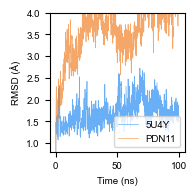


5U4Y PDN12


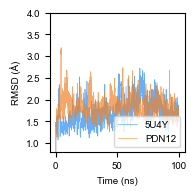


5U4Y PDN13


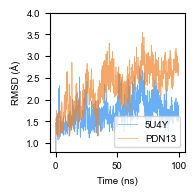


5U4Y PDN14


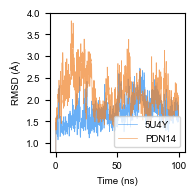


5U4Y PDN15


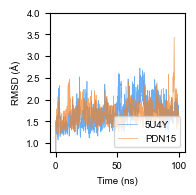


5U4Y PDN16


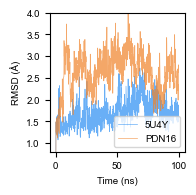


5U4Y PDN17


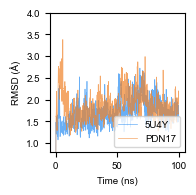


5U4Y PDN18


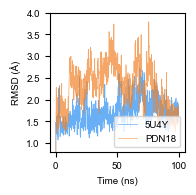


5U4Y PDN19


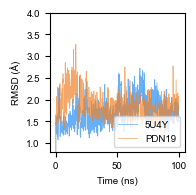


5U4Y PDN20


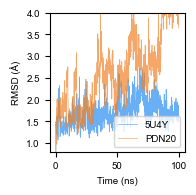


5U4Y PDN21


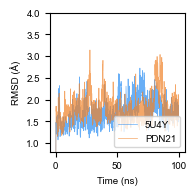


5U4Y PDN22


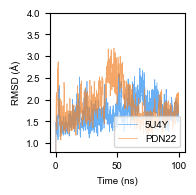


5U4Y PDN23


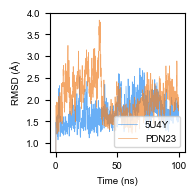


5U4Y PDN24


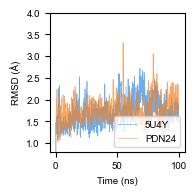

Data shape: (1001, 16)

Columns: ['Time', '5U4Y', 'PDN25', 'PDN26', 'PDN27', 'PDN28', 'PDN29', 'PDN30', 'PDN31', 'PDN32', 'PDN33', 'PDN34', 'PDN35', 'PDN36', 'PDN37', 'PDN38']

First rows:
   Time   5U4Y  PDN25  PDN26  PDN27  PDN28  PDN29  PDN30  PDN31  PDN32  PDN33  \
0   0.0  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000   
1   0.1  1.473  1.298  1.344  1.869  1.544  1.365  1.303  1.179  1.532  1.318   
2   0.2  1.481  1.167  1.558  1.428  1.298  1.219  1.403  1.261  1.233  1.521   
3   0.3  1.275  1.337  2.215  1.715  1.553  1.416  1.434  1.053  1.748  1.418   
4   0.4  1.205  1.315  2.470  1.255  1.554  1.234  1.324  1.382  1.733  1.426   

   PDN34  PDN35  PDN36  PDN37  PDN38  
0  0.000  0.000  0.000  0.000  0.000  
1  1.556  1.182  1.287  1.529  0.996  
2  1.750  1.634  1.405  1.581  1.247  
3  1.428  1.817  1.703  1.556  1.359  
4  1.611  2.205  1.253  1.452  1.519  

5U4Y PDN25


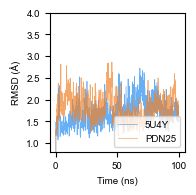


5U4Y PDN26


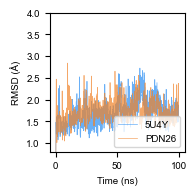


5U4Y PDN27


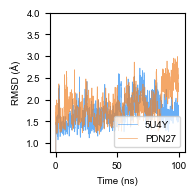


5U4Y PDN28


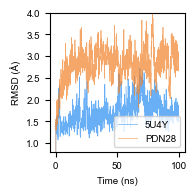


5U4Y PDN29


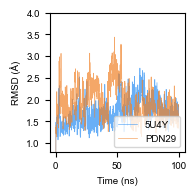


5U4Y PDN30


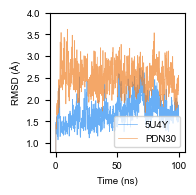


5U4Y PDN31


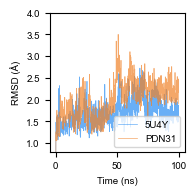


5U4Y PDN32


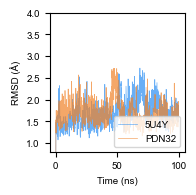


5U4Y PDN33


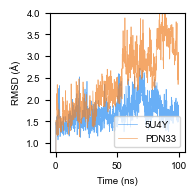


5U4Y PDN34


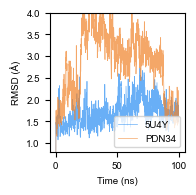


5U4Y PDN35


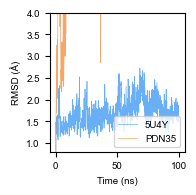


5U4Y PDN36


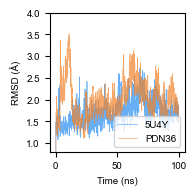


5U4Y PDN37


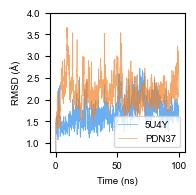


5U4Y PDN38


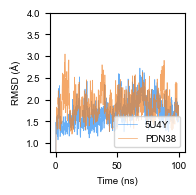

In [4]:
csv_file_path = "data/Round2_rmsd.csv"
plot_protein_rmsd("data/Round2_rmsd.csv")
plot_protein_rmsd("data/Round3_rmsd.csv")

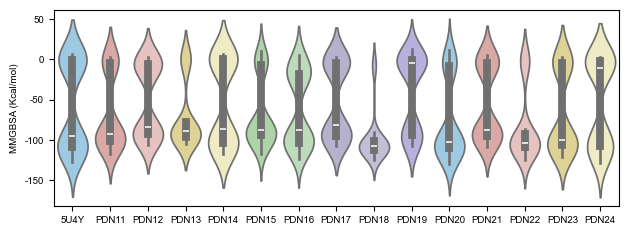

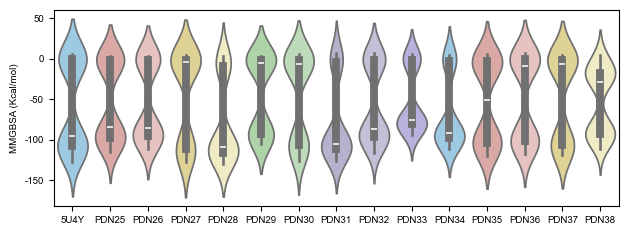

In [5]:
palette =  ["#82D0FF","#F09890", "#F6B5B0","#FBE579", "#FFF8B5","#A0E399", "#B2E8AC","#B0A6D8", "#BFB6E0","#AE9EF0"]
palette = [
    "#92CCEF",
    "#E4A29C",
    "#EDBCB9",
    "#EBDA89",
    "#F6F1BE",
    "#A8DAA2",
    "#B8E0B4",
    "#B4ACD2",
    "#C2BBDB",
    "#B4A8E6",
    "#92CCEF",
    "#E4A29C",
    "#EDBCB9",
    "#EBDA89",
    "#F6F1BE",
]
plot_violin(csv_file = 'data/Round2-MMGBSA.csv',save_file = 'Round2-MMGBSA.svg')
plot_violin(csv_file = 'data/Round3-MMGBSA.csv',save_file = 'Round3-MMGBSA.svg')

In [6]:
colors = ['#ffffcc', '#ffeda0', '#feb24c', '#f03b20', '#bd0026']
cmap = plt.get_cmap('OrRd')
hex_colors = [to_hex(cmap(i)) for i in range(cmap.N)]
custom_warm = LinearSegmentedColormap.from_list('custom_warm', hex_colors[:-70])
cmap = custom_warm

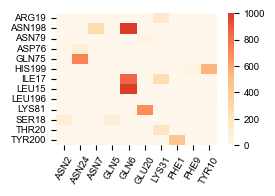

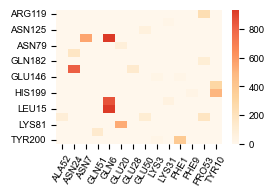

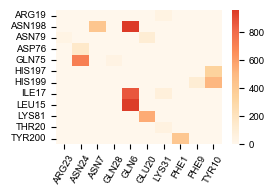

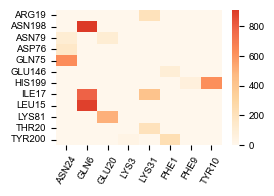

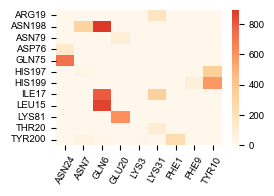

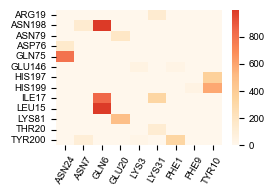

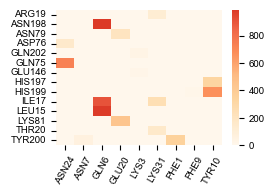

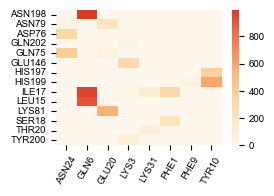

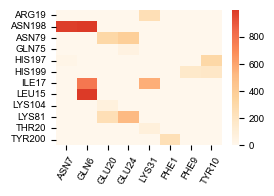

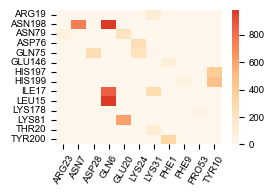

In [7]:
txt_dir  = 'data'
names = '5U4Y PDN12 PDN15 PDN17 PDN19 PDN25 PDN26 PDN29 PDN31 PDN32'.split(' ')
for name in names:
    csv_file = txt_dir + f'/{name}.txt'
    save_file = f'./{name}-ppi'
    plot_ppi(csv_file, save_file)